In [ ]:
import os
import warnings
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from metpy.plots import USCOUNTIES
import metpy.calc as mpcalc
import metpy.units as units
from scipy.ndimage import gaussian_filter
import geopandas as gpd
import imageio

from herbie import Herbie, paint

warnings.filterwarnings("ignore")

In [1]:
start_time = pd.to_datetime('2025-04-27 12:00')
sfc_list = []
wind_list = []

for fxx in range(0,49):
    H = Herbie(start_time, model='hrrr', product='prs', priority='google', fxx=fxx)
    path_v = H.download(f':DPT:2 m above ground:|:TMP:2 m above ground:|:MSLMA:')
    path_wind = H.download(f':UGRD:10 m above ground:|:VGRD:10 m above ground:')
    ds_wind = xr.open_dataset(path_wind, engine='cfgrib')
    ds_sfc = xr.open_dataset(path_v, engine='cfgrib')
    wind_list.append(ds_wind)
    sfc_list.append(ds_sfc)
sfc = xr.concat(sfc_list, dim="step")
wind = xr.concat(wind_list, dim="step")

✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-Apr-27 12:00 UTC F00 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-Apr-27 12:00 UTC F01 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-Apr-27 12:00 UTC F02 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-Apr-27 12:00 UTC F03 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-Apr-27 12:00 UTC F04 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-Apr-27 12:00 UTC F05 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-Apr-27 12:00 UTC F06 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-Apr-27 12:00 UTC F07 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-Apr-27 12:00 UTC F08 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-Apr-27 12:00 UTC F09 ┊ GRIB2 @ google ┊ IDX @ google
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2025-Apr-27 1

In [2]:
import metpy.units as units

u = wind.u10.values* 1.94384
v = wind.v10.values* 1.94384

winds = np.sqrt((u**2) + (v**2))
prs = sfc.mslma.values /100
temp = sfc.t2m.values - 273.15
dpt = sfc.d2m.values - 273.15
thte = mpcalc.equivalent_potential_temperature(prs* units.units.hPa, temp *units.units.degC , dpt*units.units.degC)

lat = wind.latitude.values
lon = wind.longitude.values



v_time = wind.valid_time.values[0]
formatted_time = pd.to_datetime(v_time).strftime('%Y-%m-%d %H:%M')
valid_times = wind.valid_time.values
run_time = wind.valid_time.values[0]
hour_int = pd.to_datetime(run_time).hour

# COD COLORMAP

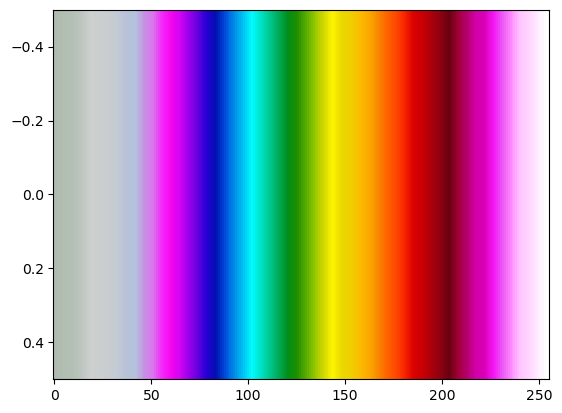

In [3]:
colors = [
    (0.0000, "#b0bbb0"),
    (0.0182, "#b1beb1"),
    (0.0364, "#b4c0b5"),
    (0.0545, "#bec6c1"),
    (0.0727, "#cfd1d1"),
    (0.0909, "#cccfcf"),
    (0.1091, "#c9cdcf"),
    (0.1273, "#c4cbd6"),
    (0.1455, "#b8c3d9"),
    (0.1636, "#b5c2dd"),
    (0.1818, "#c691e3"),
    (0.2000, "#da75ed"),
    (0.2182, "#f527fb"),
    (0.2364, "#f506ee"),
    (0.2545, "#d305f5"),
    (0.2727, "#9a00eb"),
    (0.2909, "#6000e0"),
    (0.3091, "#2600d5"),
    (0.3273, "#0110b1"),
    (0.3455, "#004ddc"),
    (0.3636, "#0087e7"),
    (0.3818, "#00c0f3"),
    (0.4000, "#00fafe"),
    (0.4182, "#00e5ca"),
    (0.4364, "#00c890"),
    (0.4545, "#00ab57"),
    (0.4727, "#008e1d"),
    (0.4909, "#1d8e00"),
    (0.5091, "#58aa00"),
    (0.5273, "#92c800"),
    (0.5455, "#cfd700"),
    (0.5636, "#fff400"),
    (0.5818, "#e9d800"),
    (0.6000, "#edd200"),
    (0.6182, "#fabe00"),
    (0.6364, "#fda900"),
    (0.6545, "#f98e00"),
    (0.6727, "#fe6600"),
    (0.6909, "#fe4b00"),
    (0.7091, "#fb2900"),
    (0.7273, "#dd0200"),
    (0.7455, "#ca0004"),
    (0.7636, "#ae010b"),
    (0.7818, "#910111"),
    (0.8000, "#690111"),
    (0.8182, "#a10134"),
    (0.8364, "#b5006a"),
    (0.8545, "#d200a7"),
    (0.8727, "#da01b8"),
    (0.8909, "#f514f3"),
    (0.9091, "#ec5bf7"),
    (0.9273, "#ff8cff"),
    (0.9455, "#ffc5ff"),
    (0.9636, "#ffd6ff"),
    (0.9818, "#ffeeff"),
    (1.0000, "#ffffff")
]
cmap = LinearSegmentedColormap.from_list('COD Theta', colors) 
plt.colormaps.register(cmap=cmap)
gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.imshow(gradient, aspect='auto', cmap=cmap)

In [8]:
def generate_thte(formatted_time, thte, u,v, lon, lat, central_lat=None, central_lon=None, horizontal_expansion=None, vertical_expansion=None):
    """
    Generate a GIF of quantitative precipitation forecasts.

    Parameters:
        formatted_time (str): The run time in the format '%Y-%m-%d %H:%M'.
        precip (ndarray): A 3D numpy array of precipitation data with dimensions (time, lat, lon).
        lon (ndarray): An array of longitude values matching the precip grid.
        lat (ndarray): An array of latitude values matching the precip grid.
        central_lat (float, optional): Central latitude for the plot extent. Defaults to 41.8781.
        central_lon (float, optional): Central longitude for the plot extent. Defaults to -87.6298.
        horizontal_expansion (float, optional): Adjustment to the east-west plot extent. Defaults to 0.
        vertical_expansion (float, optional): Adjustment to the north-south plot extent. Defaults to 0.

    Returns:
        None. The function saves the generated GIF as 'my_animation_pcp.gif' in the current directory.
    """
   

    new_dir = 'frames'
    os.makedirs(new_dir, exist_ok=True)
    os.makedirs('animations', exist_ok=True)
    counties = gpd.read_file('cb_2018_us_county_5m.shp')
    

    run_time = datetime.strptime(formatted_time, '%Y-%m-%d %H:%M')
    central_lat = central_lat if central_lat is not None else 41.8781 
    central_lon = central_lon if central_lon is not None else -87.6298
    horizontal_expansion = 0 if horizontal_expansion is None else horizontal_expansion
    vertical_expansion = 0 if vertical_expansion is None else vertical_expansion
    extent = 1.75
    north = central_lat + extent + vertical_expansion
    south = central_lat - extent + vertical_expansion
    east  = central_lon + extent + horizontal_expansion
    west  = central_lon - extent + horizontal_expansion

    chicago_lat = 41.8781
    chicago_lon = -87.6298

    filenames = []
    for t in range(0, 49):
        fig, ax = plt.subplots(
            figsize=(8, 6),
            subplot_kw={'projection': ccrs.PlateCarree()},
            dpi=150
        )
        ax.set_extent([west, east, south, north], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor='white')
        ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
        ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=1.2, linestyle=':')
        ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1.2)
        ax.plot(chicago_lon, chicago_lat, marker='o', color='red', markersize=6,
                transform=ccrs.PlateCarree())
        counties.boundary.plot(ax=ax, linewidth=0.2, color='#202020', transform=ccrs.PlateCarree(), zorder=3.9)
        norm = mcolors.Normalize(vmin=240, vmax=380)
        thte_levels = np.arange(240, 381, 2.5)
        thte_cnt = ax.contourf(
            lon, lat, thte[t, :, :],
            levels=thte_levels,
            cmap='COD Theta',
            norm=norm,
            alpha=1,
            transform=ccrs.PlateCarree()
        )


        barb_step = 6
        u2d = u[t] if u.ndim == 3 else u
        v2d = v[t] if v.ndim == 3 else v
        lon_barbs = lon[::barb_step, ::barb_step]
        lat_barbs = lat[::barb_step, ::barb_step]
        u_barbs   = u2d[::barb_step, ::barb_step]
        v_barbs   = v2d[::barb_step, ::barb_step]
        ax.barbs(
            lon_barbs, lat_barbs,
            u_barbs, v_barbs,
            transform=ccrs.PlateCarree(),
            length=4, alpha=0.9,
            sizes=dict(spacing=0.2, height=0.5, emptybarb=0.1),
            linewidth=0.8,zorder=2
        )
        valid_time = run_time + timedelta(hours=t)
        ax.set_title(
            f"HRRR {run_time.strftime('%m/%d/%Y %HZ')}\nF{t} | Valid Time: {valid_time.strftime('%m/%d/%Y %HZ')}",
            fontsize=10, loc='left', fontweight='bold'
        )
        ax.set_title(
            f"Theta-E (K) and 10 m wind (kt)",
            fontsize=8, loc='right', fontweight='light', color='black'
        )
        ax.text(
        1.1, -0.017, "Brandon Weart, NIU",
        transform=ax.transAxes,  # Use axis coordinates (0-1)
        horizontalalignment='right',
        verticalalignment='bottom',
        fontsize=4,
        color='gray',
        alpha=0.5,
        fontweight='bold'
        )
        # cax_thte = fig.add_axes([0.88, 0.15, 0.02, 0.7])
        cbar = fig.colorbar(thte_cnt, ax=ax, orientation="vertical", label="Theta-E (K)",shrink=0.982, extend='max',pad=0.014,aspect=30)
        ticks = np.arange(240, 381, 10)
        tick_labels = np.arange(240, 381, 10)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels(tick_labels)
        plt.tight_layout()
        
        outname = os.path.join(new_dir, f"frame_{t:02d}.png")
        plt.savefig(outname, dpi=300, bbox_inches='tight')
        plt.close(fig)
        filenames.append(outname)
    images = []
    for fname in filenames:
        images.append(imageio.imread(fname))
    gif_path = os.path.join('animations', 'my_animation_thte.gif')
    imageio.mimsave(gif_path, images, loop=0, fps=4)
    print("Saved GIF => my_animation_thte.gif")


In [9]:
generate_thte(formatted_time, thte, u,v, lon, lat)

Saved GIF => my_animation_thte.gif


In [60]:
H = Herbie('2025-04-22 12:00',model='gfs', product='pgrb2.0p25', priority='google', fxx=300)

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2025-Apr-22 12:00 UTC F300 ┊ GRIB2 @ google ┊ IDX @ google


In [54]:
H.inventory('APCP')

,grib_message,start_byte,end_byte,range,reference_time,valid_time,variable,level,forecast_time,search_this
595,596,436752671,437119494.0,436752671-437119494,2025-04-22 12:00:00,2025-05-05,APCP,surface,294-300 hour acc fcst,:APCP:surface:294-300 hour acc fcst
596,597,437119495,438007939.0,437119495-438007939,2025-04-22 12:00:00,2025-05-05,APCP,surface,0-300 hour acc fcst,:APCP:surface:0-300 hour acc fcst
